Loading landmark data...
Loaded 3237 landmark frames
Loading clip ranges...
Loaded 112 clip segments
Loading contact/separation annotations...
Loaded 112 contact/separation pairs

=== Annotation Validation (First 10 sets) ===
Clip ranges: 10 entries
CS annotations: 10 entries
✅ Clip 1: Contact 51, Separation 71 (within 43-80)
✅ Clip 2: Contact 103, Separation 120 (within 91-127)
✅ Clip 3: Contact 145, Separation 166 (within 138-173)
✅ Clip 4: Contact 191, Separation 216 (within 183-222)
✅ Clip 5: Contact 246, Separation 269 (within 237-276)
✅ Clip 6: Contact 297, Separation 319 (within 290-325)
✅ Clip 7: Contact 346, Separation 366 (within 337-372)
✅ Clip 8: Contact 391, Separation 415 (within 385-422)
✅ Clip 9: Contact 448, Separation 478 (within 434-483)
✅ Clip 10: Contact 505, Separation 524 (within 496-533)

Processing landmarks by clips (velocity only, first 10 sets)...
Processing only first 10 clip sets...
Clip 1 (43-80): Found 30 landmark frames
Clip 2 (91-127): Found 28 landmar

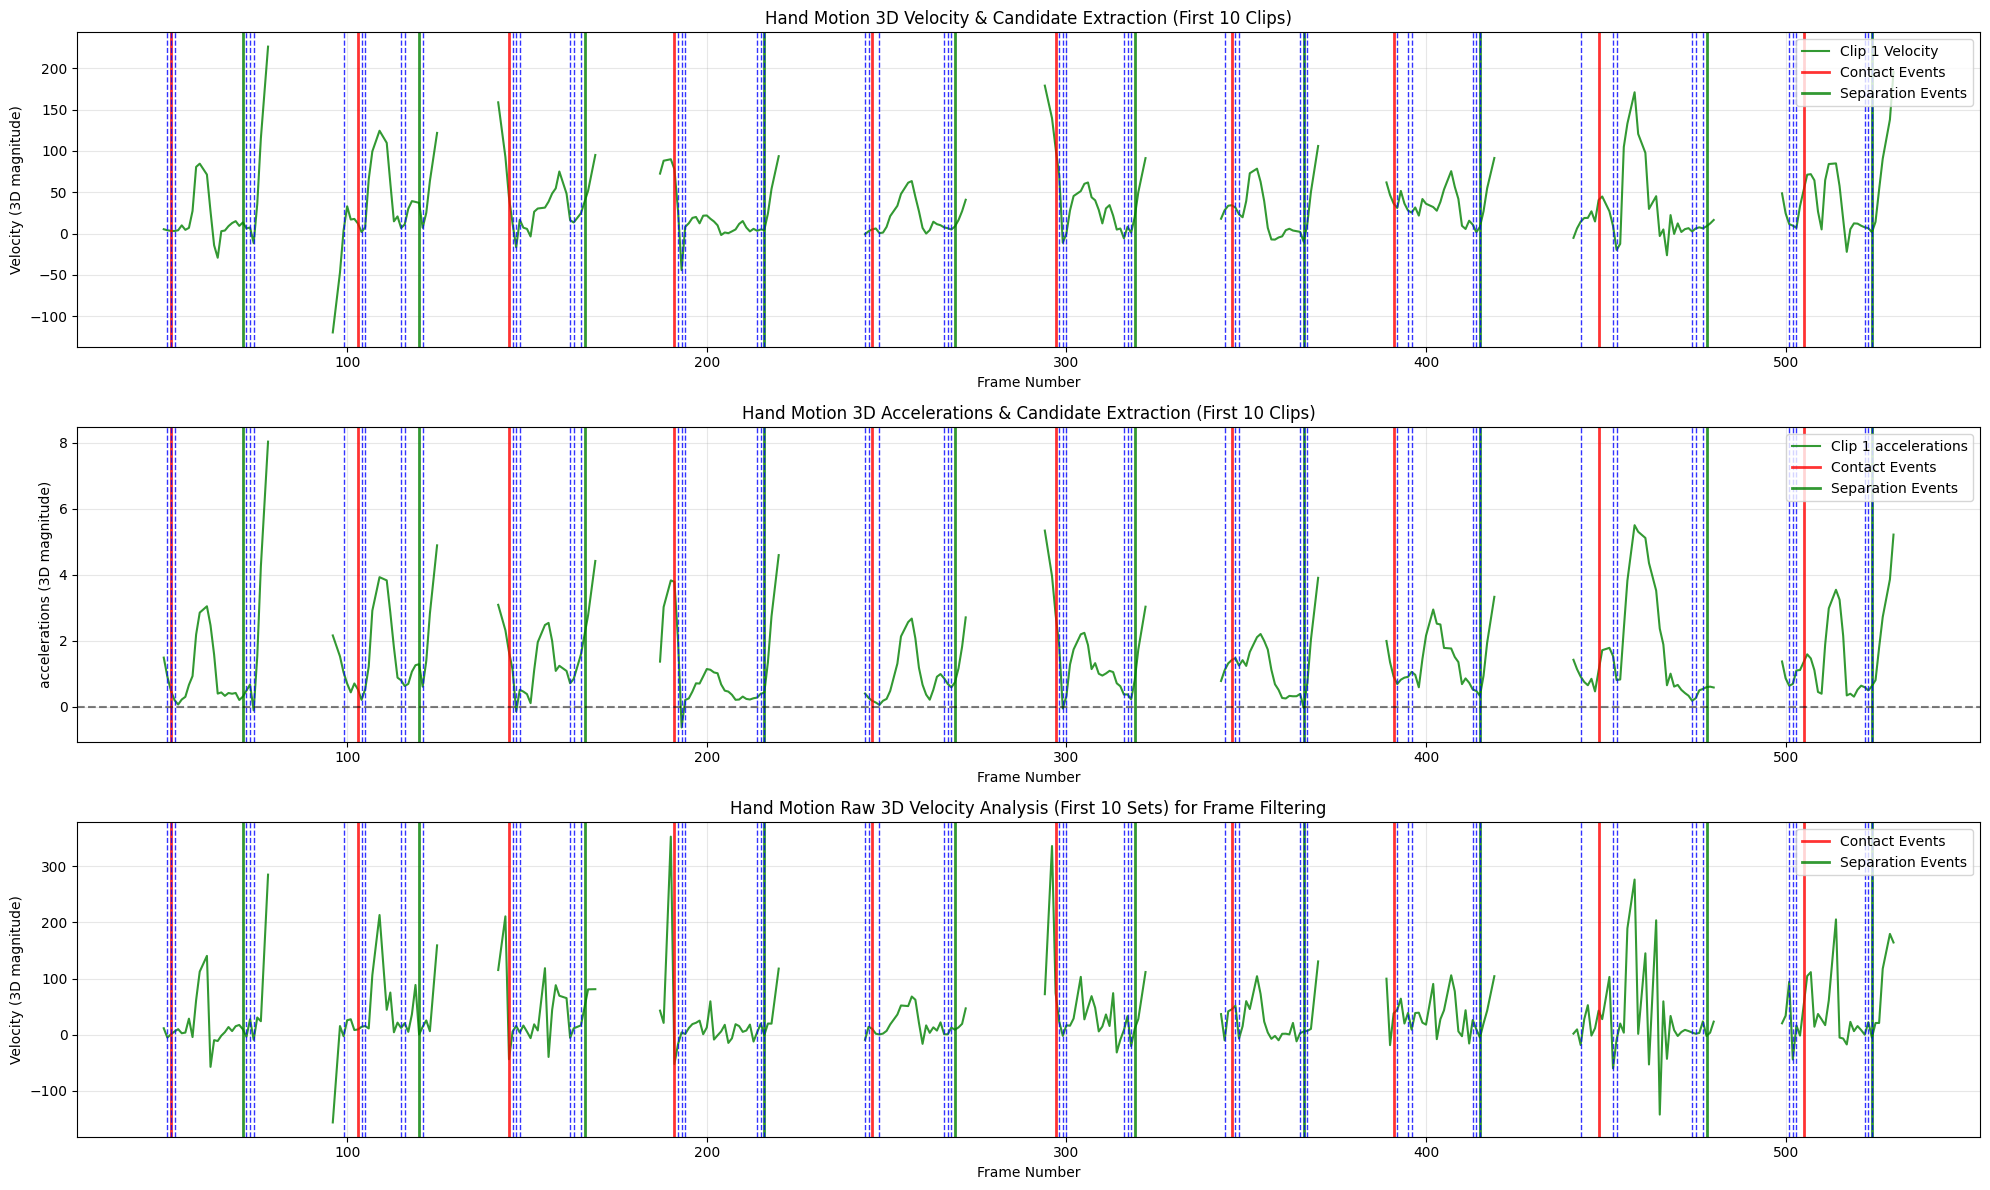

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.signal import savgol_filter

NUM_SETS_MAX = 10

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    with open(filename, 'r') as file:
        content = file.read()
    frame_blocks = re.split(r'(\d+):', content)
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    return landmarks_data

def parse_clip_ranges(filename):
    """Parse clip ranges file with robust error handling."""
    clip_ranges = []
    with open(filename, 'r') as file:
        lines = file.readlines()
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:
            continue
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    return clip_ranges

def parse_cs_annot(filename):
    """Parse contact and separation annotations with robust error handling."""
    cs_annotations = []
    with open(filename, 'r') as file:
        lines = file.readlines()
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:
            continue
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    return cs_annotations

def validate_annotations(clip_ranges, cs_annotations, num_sets=None):
    """Validate that contact/separation frames are within clip boundaries."""
    if num_sets is not None:
        clip_ranges = clip_ranges[:num_sets]
        cs_annotations = cs_annotations[:num_sets]
    print(f"\n=== Annotation Validation (First {len(clip_ranges)} sets) ===")
    print(f"Clip ranges: {len(clip_ranges)} entries")
    print(f"CS annotations: {len(cs_annotations)} entries")
    if len(clip_ranges) != len(cs_annotations):
        print(f"⚠️  MISMATCH: {len(clip_ranges)} clips vs {len(cs_annotations)} annotations")
        return False
    validation_passed = True
    for i, ((start, end), (contact, separation)) in enumerate(zip(clip_ranges, cs_annotations)):
        clip_num = i + 1
        if not (start <= contact <= end):
            print(f"❌ Clip {clip_num}: Contact frame {contact} outside range ({start}-{end})")
            validation_passed = False
        if not (start <= separation <= end):
            print(f"❌ Clip {clip_num}: Separation frame {separation} outside range ({start}-{end})")
            validation_passed = False
        if contact >= separation:
            print(f"❌ Clip {clip_num}: Contact {contact} should be before separation {separation}")
            validation_passed = False
        if validation_passed:
            print(f"✅ Clip {clip_num}: Contact {contact}, Separation {separation} (within {start}-{end})")
    return validation_passed

def calculate_hand_tangential_acceleration(landmarks, fps=30):
    """
    Calculate only the velocity magnitudes for frame-wise hand motion, 3D.
    Returns (velocity_magnitudes, dummy_accelerations)
    """
    
    if len(landmarks) < 3:
        return [], []
    
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    
    velocities = np.diff(positions, axis=0) / dt
    accelerations = np.diff(velocities, axis=0) / dt
    
    velocity_magnitudes = np.linalg.norm(velocities[1:], axis=1)
    
    tangential_accelerations = []
    
    for i in range(len(accelerations)):
        velocity_vec = velocities[i + 1]  
        acceleration_vec = accelerations[i] 
        velocity_magnitude = np.linalg.norm(velocity_vec)
        
        if velocity_magnitude > 1e-10: 
            tangential_acc = np.dot(acceleration_vec, velocity_vec) / velocity_magnitude
            tangential_accelerations.append(tangential_acc)
        else:
            tangential_accelerations.append(0.0)
    
    return tangential_accelerations, velocity_magnitudes.tolist()


def apply_smooth_vel_acc(vel_list, window=5, poly=3):
    """
    Apply Savitzky–Golay filter to velocity samples (optional, for visualization).
    """
    if len(vel_list) < window:
        return vel_list
    return savgol_filter(vel_list, window, poly).tolist()


def process_landmarks_by_clips_velocity_only(landmarks_data, clip_ranges, fps=30, num_sets=None):
    """Process landmarks by clips, collecting only velocity data (candidate extraction)."""
    if num_sets is not None:
        clip_ranges = clip_ranges[:num_sets]
        print(f"Processing only first {num_sets} clip sets...")
    clip_data = []
    for clip_idx, (start_frame, end_frame) in enumerate(clip_ranges):
        clip_frames = []
        clip_landmarks = []
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        print(f"Clip {clip_idx + 1} ({start_frame}-{end_frame}): Found {len(clip_landmarks)} landmark frames")
        if len(clip_landmarks) >= 3:  # Need at least 2 for velocity
            velocities, accelerations = calculate_hand_tangential_acceleration(clip_landmarks, fps)
            velocities_smooth = apply_smooth_vel_acc(velocities, window=7, poly=2)
            accelerations_smooth = apply_smooth_vel_acc(accelerations, window=7, poly=2)
            # Velocity is aligned: first diff between frame1 & frame2 = frame2
            vel_frames = clip_frames[2:]
            clip_data.append({
                'frames': vel_frames,
                'velocities': velocities_smooth,
                'clip_range': (start_frame, end_frame),
                'clip_index': clip_idx,
                'velocities_raw': velocities,
                'accelerations': accelerations_smooth,  # Not used
                'accelerations_raw' : accelerations
            })
        else:
            print(f"⚠️  Clip {clip_idx + 1}: Not enough landmarks for velocity analysis")
    return clip_data

def event_trend_candidates(
    frames, velocities, accelerations, annotation_frame,
    window=8, plateau_percentile=40, max_candidates=3):

    # Select window of frames around annotation
    idx_window = [i for i, f in enumerate(frames) if annotation_frame - window <= f <= annotation_frame + window]
    if not idx_window:
        return []  # No frames in window

    vels = [velocities[i] for i in idx_window]
    accs = [accelerations[i] for i in idx_window]

    # Find minimum velocity (slowest point) in window as base
    min_idx = np.argmin(vels)
    base_frame = frames[idx_window[min_idx]]
    candidates = [base_frame]

    # Plateau detection: frames within percentile of lowest velocity in window
    low_vel_thresh = np.percentile(vels, plateau_percentile)
    for j, v in enumerate(vels):
        if v <= low_vel_thresh and frames[idx_window[j]] not in candidates:
            candidates.append(frames[idx_window[j]])

    # Zero-crossings in acceleration (direction changes)
    for k in range(1, len(accs)):
        if accs[k-1] * accs[k] < 0:
            for f in [frames[idx_window[k-1]], frames[idx_window[k]]]:
                if f not in candidates:
                    candidates.append(f)

    # Local inflection: just before velocity rises
    for k in range(min_idx-1, min_idx+2):
        if 0 <= k < len(vels)-1:
            if vels[k+1] > vels[k]:
                if frames[idx_window[k]] not in candidates:
                    candidates.append(frames[idx_window[k]])

    # De-duplicate, sort by proximity to annotation, then velocity value
    candidates = sorted(set(candidates), key=lambda f: (abs(f - annotation_frame), velocities[frames.index(f)]))
    return candidates[:max_candidates]


def plot_velocity_and_candidates(clip_data, cs_annotations, trend_candidates,  num_sets=None, candidate_n=5):
    """Plot velocity for each clip and overlay candidate frames selected by filtering logic."""
    if num_sets is not None:
        clip_data = clip_data[:num_sets]
        cs_annotations = cs_annotations[:num_sets]
        print(f"Plotting first {num_sets} sets of graphs...")

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 12))

    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['velocities'], 'g-', linewidth=1.5, alpha=0.8, label=f'Clip {i + 1} Velocity' if i == 0 else "")
        all_velocities.extend(clip['velocities'])
        
    contact_label_added = False
    separation_label_added = False

    annotation_count = min(len(clip_data), len(cs_annotations))
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                    label='Contact Events')
            contact_label_added = True
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                    label='Separation Events')
            separation_label_added = True
        else:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    for frames in trend_candidates:
        all_frame = frames["contact_candidates"] + frames["separation_candidates"]
        for frame in all_frame:
            ax1.axvline(x=frame, color = "blue", linestyle = "--", alpha = 0.8, linewidth = 1)

    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Velocity (3D magnitude)')
    ax1.set_title(f'Hand Motion 3D Velocity & Candidate Extraction (First {len(clip_data)} Clips)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')


    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['accelerations'], 'g-', linewidth=1.5, alpha=0.8, label=f'Clip {i + 1} accelerations' if i == 0 else "")
        all_accelerations.extend(clip['accelerations'])
        
        
    contact_label_added = False
    separation_label_added = False

    annotation_count = min(len(clip_data), len(cs_annotations))
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                    label='Contact Events')
            contact_label_added = True
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                    label='Separation Events')
            separation_label_added = True
        else:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    for frames in trend_candidates:
        all_frames = frames["contact_candidates"] + frames["separation_candidates"]
        for frame in all_frames:
            ax2.axvline(x=frame, color = "blue", linestyle = "--", alpha = 0.8, linewidth = 1)

    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('accelerations (3D magnitude)')
    ax2.set_title(f'Hand Motion 3D Accelerations & Candidate Extraction (First {len(clip_data)} Clips)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')


    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax3.plot(clip['frames'], clip['velocities_raw'], 'g-', 
                linewidth=1.5, alpha=0.8)
        all_velocities.extend(clip['velocities_raw'])
    
    ax3.set_xlabel('Frame Number')
    ax3.set_ylabel('Velocity (3D magnitude)')
    ax3.set_title(f'Hand Motion Raw 3D Velocity Analysis (First {len(clip_data)} Sets) for Frame Filtering')
    ax3.grid(True, alpha=0.3)
    
    contact_label_added = False
    separation_label_added = False
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax3.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax3.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax3.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax3.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)

    for frames in trend_candidates:
        all_frames = frames["contact_candidates"] + frames["separation_candidates"]
        for frame in all_frames:
            ax3.axvline(x=frame, color = "blue", linestyle = "--", alpha = 0.8, linewidth = 1)

    ax3.legend(loc='upper right')


    plt.tight_layout()
    plt.show()
    return fig


def main():
    """Main function with velocity-based candidate extraction and plotting (acceleration data ignored)."""
    landmarks_file = "../test_data/5th_landmarks_bC1.txt"
    clip_ranges_file = "../bathroomCabinet_1/clip_ranges.txt"
    cs_annot_file = "../test_data/cs_annot_cabinet_1.txt"
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    validation_passed = validate_annotations(clip_ranges, cs_annotations, num_sets=NUM_SETS_MAX)
    if not validation_passed:
        print("⚠️  Validation failed, but continuing with analysis...")
    print(f"\nProcessing landmarks by clips (velocity only, first {NUM_SETS_MAX} sets)...")
    clip_data = process_landmarks_by_clips_velocity_only(
        landmarks_data, clip_ranges, fps=30, num_sets=NUM_SETS_MAX)
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    print(f"\nTotal velocity frames processed: {total_frames}")
    print(f"Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
    print("\nCandidate frames for each clip (slowest velocity):")

    trend_candidates = []
    for i, clip in enumerate(clip_data):
        frames = clip['frames']
        velocities = clip['velocities']
        accelerations = clip['accelerations']
        contact, separation = cs_annotations[i]
        cands = {
            "contact_candidates": event_trend_candidates(frames, velocities, accelerations, contact, window=8, plateau_percentile=40, max_candidates=3),
            "separation_candidates": event_trend_candidates(frames, velocities, accelerations, separation, window=8, plateau_percentile=40, max_candidates=3),
        }
        trend_candidates.append(cands)

    for candidate in trend_candidates:
        candidate_frames = candidate["contact_candidates"] + candidate["separation_candidates"]
        print(candidate_frames)

    fig = plot_velocity_and_candidates(clip_data, cs_annotations, trend_candidates, num_sets=NUM_SETS_MAX, candidate_n=5)
    return {
        'clip_data': clip_data,
        'cs_annotations': cs_annotations[:NUM_SETS_MAX],
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges[:NUM_SETS_MAX],
        'validation_passed': validation_passed
    }

if __name__ == "__main__":
    results = main()


In [1]:
import os
print(os.listdir("C:/Users/Hp/AppData/Local/Programs/Python/Python310/Lib/site-packages"))


['3204bda914b7f2c6f497__mypyc.cp310-win_amd64.pyd', 'absl', 'absl_py-2.1.0.dist-info', 'adodbapi', 'aiohappyeyeballs', 'aiohappyeyeballs-2.6.1.dist-info', 'aiohttp', 'aiohttp-3.11.18.dist-info', 'aiosignal', 'aiosignal-1.3.2.dist-info', 'alpha_vantage', 'alpha_vantage-3.0.0.dist-info', 'asttokens', 'asttokens-3.0.0.dist-info', 'astunparse', 'astunparse-1.6.3.dist-info', 'async_timeout', 'async_timeout-5.0.1.dist-info', 'attr', 'attrs', 'attrs-25.1.0.dist-info', 'awscli', 'awscli-1.41.4.dist-info', 'boto3', 'boto3-1.39.4.dist-info', 'botocore', 'botocore-1.39.4.dist-info', 'caer', 'caer-2.0.8.dist-info', 'certifi', 'certifi-2025.1.31.dist-info', 'cffi', 'cffi-1.17.1.dist-info', 'charset_normalizer', 'charset_normalizer-3.4.1.dist-info', 'clang', 'colorama', 'colorama-0.4.6.dist-info', 'comm', 'comm-0.2.2.dist-info', 'contourpy', 'contourpy-1.3.2.dist-info', 'cv2', 'cycler', 'cycler-0.12.1.dist-info', 'dataclasses_json', 'dataclasses_json-0.6.7.dist-info', 'dateutil', 'debugpy', 'debugpy